# Trinity-AI — Pipeline Walkthrough
## Auditoría Human-in-the-Loop: Credit Risk Scoring (IBM Bob 2.0 Hackathon)

---

Este notebook es un **recorrido de auditoría interactivo** diseñado para que el Data Scientist humano valide cada etapa del pipeline de scoring de riesgo crediticio antes de promover el modelo a producción.

**Flujo de ejecución:**
```
Setup → Carga & Validación → Preprocesamiento & Split → Entrenamiento → Evaluación → Decisión Humana
```

**Targets de negocio (ADR-006 + ADR-008):**
| Métrica | Target mínimo | Restricción |
|---|---|---|
| ROC-AUC | ≥ 0.78 | Obligatorio |
| KS | ≥ 0.33 | Obligatorio |
| Recall clase 1 | ≥ 0.55 | **Dura** (costo FN) |
| Latencia P95 | < 50ms | Obligatorio |

> ⚠️ **Instrucción:** Ejecutar las celdas en orden. La Celda 6 requiere intervención manual del Data Scientist.

---
## Celda 1 — Setup del Entorno
Verificación del entorno `dsenv`, imports limpios desde `src/` y configuración de logging para trazabilidad completa durante la auditoría.

In [1]:
import sys
import logging
from pathlib import Path

# --- Ancla de ruta: project root ---
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Logging legible para auditoría ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s — %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)
logger = logging.getLogger("walkthrough")

# --- Imports del pipeline Trinity-AI ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data_loader import (
    load_dataset,
    OBJECT_COLS_GROUP_D,
    FLOAT_COLS_NO_NULL,
    TARGET_COL,
    DATE_COL,
)
from src.features import build_features, SplitResult
from src.model import train_model, TrainResult, BASE_PARAMS
from src.evaluate import evaluate_model, compute_ks, update_metrics_json, METRICS_JSON_PATH

# --- Estilo global de gráficos ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# --- Versiones para reproducibilidad ---
import lightgbm as lgb
import sklearn
import pydantic

print("\n✅ Entorno verificado")
print(f"   Python        : {sys.version.split()[0]}")
print(f"   pandas        : {pd.__version__}")
print(f"   numpy         : {np.__version__}")
print(f"   lightgbm      : {lgb.__version__}")
print(f"   scikit-learn  : {sklearn.__version__}")
print(f"   pydantic      : {pydantic.__version__}")
print(f"   Project root  : {PROJECT_ROOT}")

00:55:03 | INFO     | numexpr.utils — NumExpr defaulting to 16 threads.

✅ Entorno verificado
   Python        : 3.13.9
   pandas        : 2.3.3
   numpy         : 2.3.5
   lightgbm      : 4.7.0
   scikit-learn  : 1.7.2
   pydantic      : 2.12.4
   Project root  : C:\Users\edgde\OneDrive\desarrolloProj\bob_hack\bob_hack


---
## Celda 2 — Carga del Dataset y Validación Pydantic

Se carga `data/data_ejm.parquet` a través de `data_loader.load_dataset()`, que realiza:
1. **Normalización de Grupo D**: columnas con formato numérico latinoamericano (`'383.722.966'` → `383722966`) convertidas con `str.replace('.', '')` antes del cast.
2. **Validación Pydantic v2**: muestra de 500 registros contra el modelo `RawRecord`. Falla con `ValueError` si >1% son inválidos.

> 🔍 **Auditar**: revisar el conteo de nulos por grupo de columnas y confirmar que la tasa de registros inválidos es 0%.

In [2]:
PARQUET_PATH = PROJECT_ROOT / "data" / "data_ejm.parquet"

logger.info("Cargando dataset: %s", PARQUET_PATH)
df = load_dataset(PARQUET_PATH)

print(f"\n{'─'*55}")
print(f"  Dataset cargado y validado")
print(f"{'─'*55}")
print(f"  Shape          : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Target positivo: {df[TARGET_COL].mean()*100:.2f}% ({df[TARGET_COL].sum():,} casos)")
print(f"  Rango de fechas: {df[DATE_COL].min()} → {df[DATE_COL].max()}")
print(f"{'─'*55}")

# Nulos por grupo de columnas
null_grupoA_B_C = df[FLOAT_COLS_NO_NULL].isnull().sum().sum()
null_grupoD = df[OBJECT_COLS_GROUP_D].isnull().sum()

print(f"\nNulos Grupo A-B-C (esperado 0)  : {null_grupoA_B_C}")
print(f"\nNulos Grupo D (ratios financieros):")
print(null_grupoD[null_grupoD > 0].to_string())

# Resumen estadístico del target
target_counts = df[TARGET_COL].value_counts().rename({0: "Clase 0 (No mora)", 1: "Clase 1 (Mora)"})
print(f"\n{'─'*55}")
print("Distribución del target:")
print(target_counts.to_string())
print(f"Ratio imbalance: 1:{int(target_counts[0]/target_counts[1])}  "
      f"→ scale_pos_weight = {target_counts[0]/target_counts[1]:.2f}")

00:55:07 | INFO     | walkthrough — Cargando dataset: C:\Users\edgde\OneDrive\desarrolloProj\bob_hack\bob_hack\data\data_ejm.parquet
00:55:07 | INFO     | src.data_loader — Cargando dataset: C:\Users\edgde\OneDrive\desarrolloProj\bob_hack\bob_hack\data\data_ejm.parquet
00:55:09 | INFO     | src.data_loader — Shape inicial: (22025, 49)
00:55:10 | INFO     | src.data_loader — Validación: 0/22025 registros inválidos (0.00%)
00:55:10 | INFO     | src.data_loader — Dataset validado correctamente. Shape final: (22025, 49)

───────────────────────────────────────────────────────
  Dataset cargado y validado
───────────────────────────────────────────────────────
  Shape          : 22,025 filas × 49 columnas
  Target positivo: 10.32% (2,274 casos)
  Rango de fechas: 2022-01-31 00:00:00 → 2023-12-31 00:00:00
───────────────────────────────────────────────────────

Nulos Grupo A-B-C (esperado 0)  : 0

Nulos Grupo D (ratios financieros):
VAR_12M_PROM_DIRECTA_CNS_TC    3041
VAR_12M_PROM_DIRECTA   

C:\Users\edgde\AppData\Local\Temp\ipykernel_32256\2480344954.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Ratio imbalance: 1:{int(target_counts[0]/target_counts[1])}  "
C:\Users\edgde\AppData\Local\Temp\ipykernel_32256\2480344954.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"→ scale_pos_weight = {target_counts[0]/target_counts[1]:.2f}")


---
## Celda 3 — Preprocesamiento y Split Temporal

`features.build_features()` ejecuta:
1. **Split temporal 70/15/15** ordenado por `FECHA` ascendente — **sin shuffle** (ADR-005, evita leakage temporal).
2. **Imputación estratificada** por cuartil de `NRO_ENTS_SF`, calculada **exclusivamente sobre train** para evitar data leakage.

> 🔍 **Auditar**: confirmar que no hay solapamiento temporal entre conjuntos y que la distribución del target es similar entre splits (sin drift extremo).

00:55:10 | INFO     | walkthrough — Construyendo features y aplicando split temporal...
00:55:10 | INFO     | src.features — Split temporal → Train: 15417 | Val: 3303 | Test: 3305
00:55:10 | INFO     | src.features — Medianas de imputación calculadas sobre train (4 cuartiles).
00:55:10 | INFO     | src.features — Features construidas: 46 columnas. Distribución target → Train: 10.25% | Val: 10.84% | Test: 10.17%

────────────────────────────────────────────────────────────
  Split Temporal 70/15/15 (sin shuffle — ADR-005)
────────────────────────────────────────────────────────────
  Conjunto   N        % Total    % Positivos    N Positivos
  ───────────────────────────────────────────────────────
  Train      15,417   70.0       10.25          1,580
  Val        3,303    15.0       10.84          358
  Test       3,305    15.0       10.17          336
────────────────────────────────────────────────────────────
  Total features : 46

  Nulos residuales → Train: 0 | Val: 0 | Test: 0
  ✅

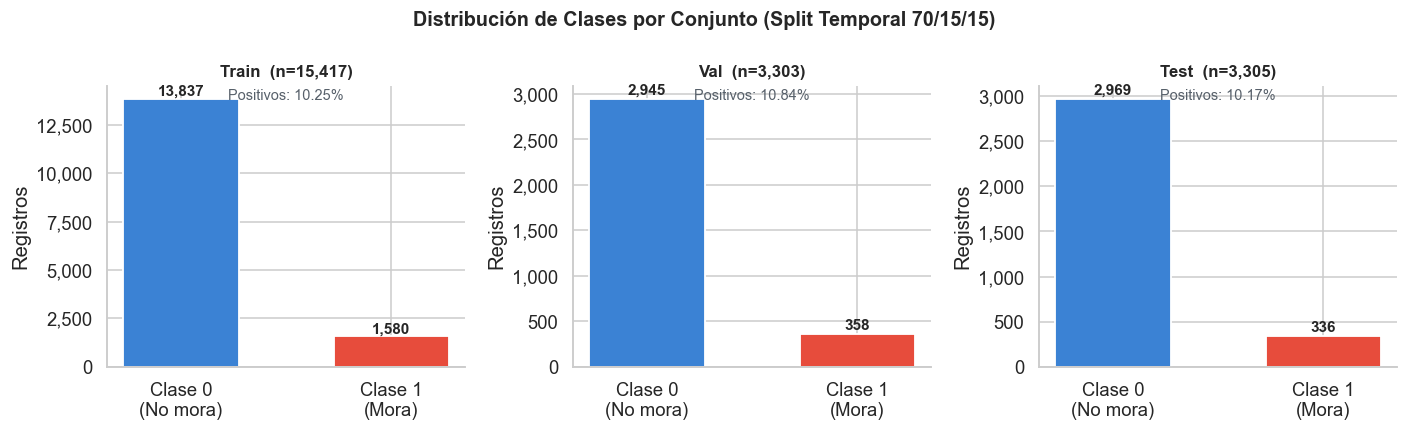

In [3]:
logger.info("Construyendo features y aplicando split temporal...")
split: SplitResult = build_features(df)

# Resumen del split
splits_info = {
    "Train": (split.X_train, split.y_train),
    "Val":   (split.X_val,   split.y_val),
    "Test":  (split.X_test,  split.y_test),
}

print(f"\n{'─'*60}")
print(f"  Split Temporal 70/15/15 (sin shuffle — ADR-005)")
print(f"{'─'*60}")
print(f"  {'Conjunto':<10} {'N':<8} {'% Total':<10} {'% Positivos':<14} {'N Positivos'}")
print(f"  {'─'*55}")
total_n = sum(len(x) for x, _ in splits_info.values())
for name, (X, y) in splits_info.items():
    pct = len(X) / total_n * 100
    pos_pct = y.mean() * 100
    print(f"  {name:<10} {len(X):<8,} {pct:<10.1f} {pos_pct:<14.2f} {y.sum():,}")
print(f"{'─'*60}")
print(f"  Total features : {len(split.feature_cols)}")

# Verificar ausencia de nulos residuales tras imputación
nulos_train = split.X_train.isnull().sum().sum()
nulos_val   = split.X_val.isnull().sum().sum()
nulos_test  = split.X_test.isnull().sum().sum()
print(f"\n  Nulos residuales → Train: {nulos_train} | Val: {nulos_val} | Test: {nulos_test}")
assert nulos_train == 0, "⛔ Nulos en X_train tras imputación — revisar features.py"
print("  ✅ Imputación completa: sin nulos residuales")

# --- Gráfico: Distribución de clases en cada conjunto ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("Distribución de Clases por Conjunto (Split Temporal 70/15/15)", fontsize=13, fontweight="bold")

colors_pos = ["#3b82d4", "#e74c3c"]
for ax, (name, (X, y)) in zip(axes, splits_info.items()):
    counts = y.value_counts().sort_index()
    bars = ax.bar(
        ["Clase 0\n(No mora)", "Clase 1\n(Mora)"],
        counts.values,
        color=colors_pos,
        width=0.55,
        edgecolor="white",
        linewidth=1.2,
    )
    for bar, count in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f"{count:,}",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )
    ax.set_title(f"{name}  (n={len(y):,})", fontsize=11, fontweight="bold")
    ax.set_ylabel("Registros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.annotate(
        f"Positivos: {y.mean()*100:.2f}%",
        xy=(0.5, 0.95), xycoords="axes fraction",
        ha="center", fontsize=9.5, color="#57606a",
    )

plt.tight_layout()
plt.show()

---
## Celda 4 — Entrenamiento LightGBM

`model.train_model()` entrena con:
- `scale_pos_weight=8.68` (ratio 19751/2274 — ADR-004) para compensar desbalance severo (10.32% positivos).
- **Early stopping en 50 rondas** sobre `val-AUC` para evitar overfitting.
- **Umbral óptimo** determinado por curva Precision-Recall sobre val, maximizando F1 sujeto a Recall ≥ 0.55 (ADR-008).

> 🔍 **Auditar**: `best_iteration` > 50 indica buen ajuste. Si `best_iteration` ≤ 10 hay señal de concept drift temporal severo.

00:55:11 | INFO     | walkthrough — Iniciando entrenamiento LightGBM...
00:55:11 | INFO     | src.model — Iniciando entrenamiento LightGBM | n_estimators=500 | scale_pos_weight=8.68


c:\Users\edgde\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	valid_0's auc: 0.591575
00:55:11 | INFO     | src.model — Entrenamiento completado. Mejor iteración: 6
00:55:11 | INFO     | src.model — Umbral óptimo: 0.2092 → Recall=0.6034 | Precision=0.1422 | F1=0.2302
00:55:11 | INFO     | src.model — Top-5 features:
VAR_12M_MED_DIRECTA     22
VAR_12M_MAX_DIRECTA     16
VAR_6M_PROM_DIRECTA     15
VAR_12M_PROM_DIRECTA    14
VAR_6M_MED_DIRECTA      11

───────────────────────────────────────────────────────
  Reporte de Entrenamiento
───────────────────────────────────────────────────────
  Mejor iteración (best_iteration) : 6
  Umbral óptimo (Recall ≥ 0.55)    : 0.2092
  Parámetros clave:
    n_estimators             : 500
    learning_rate            : 0.05
    num_leaves               : 31
    scale_pos_weight         : 8.68
    min_child_samples        : 50
    lambda_l1                : 0.1
    lambda_l2                : 0.1
    colsample_bytree         : 0.8

  ⚠️  ALERTA: best_iteration ≤ 10 — posible concept drift temporal severo.
     

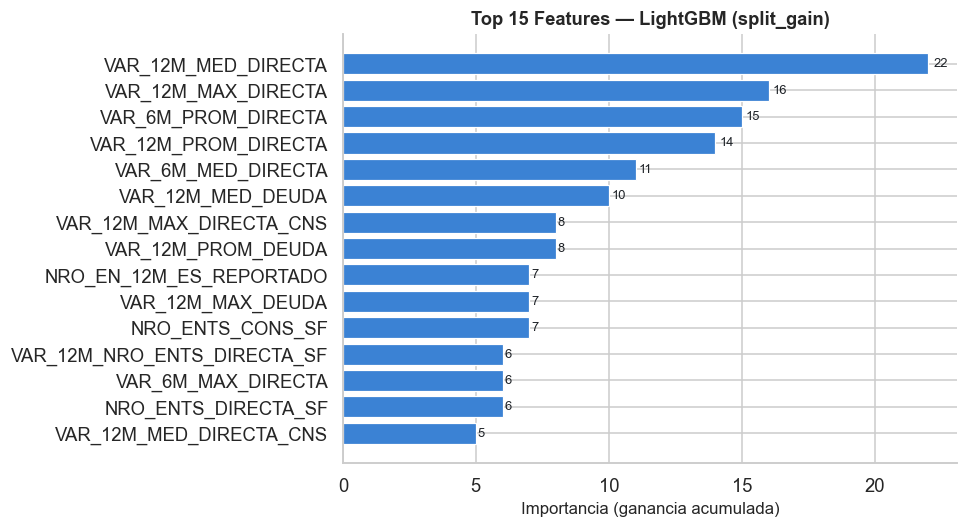

In [4]:
logger.info("Iniciando entrenamiento LightGBM...")
train_result: TrainResult = train_model(
    X_train=split.X_train,
    y_train=split.y_train,
    X_val=split.X_val,
    y_val=split.y_val,
)

print(f"\n{'─'*55}")
print(f"  Reporte de Entrenamiento")
print(f"{'─'*55}")
print(f"  Mejor iteración (best_iteration) : {train_result.best_iteration}")
print(f"  Umbral óptimo (Recall ≥ 0.55)    : {train_result.optimal_threshold:.4f}")
print(f"  Parámetros clave:")
for k in ["n_estimators", "learning_rate", "num_leaves", "scale_pos_weight",
          "min_child_samples", "lambda_l1", "lambda_l2", "colsample_bytree"]:
    print(f"    {k:<25}: {train_result.params_used.get(k)}")

# Diagnóstico de best_iteration
if train_result.best_iteration <= 10:
    print("\n  ⚠️  ALERTA: best_iteration ≤ 10 — posible concept drift temporal severo.")
    print("      Recomendación: reducir learning_rate=0.01 y analizar distribución temporal del target.")
else:
    print(f"\n  ✅ best_iteration={train_result.best_iteration} — convergencia saludable.")

# --- Gráfico: Top-15 Feature Importances ---
top_n = 15
fi = train_result.feature_importances.head(top_n)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    fi.index[::-1],
    fi.values[::-1],
    color="#3b82d4",
    edgecolor="white",
    linewidth=0.8,
)
ax.set_xlabel("Importancia (ganancia acumulada)", fontsize=11)
ax.set_title(f"Top {top_n} Features — LightGBM (split_gain)", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar in bars:
    w = bar.get_width()
    ax.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{w:,.0f}", va="center", fontsize=8.5, color="#1f2328")
plt.tight_layout()
plt.show()

---
## Celda 5 — Evaluación Exhaustiva sobre Test Set

Evaluación sobre el **15% más reciente** (holdout temporal). Se generan tres artefactos visuales:

1. **Curva ROC-AUC** — capacidad discriminante independiente del umbral.
2. **Curva Precision-Recall** — más informativa que ROC en datasets desbalanceados; marcador del umbral óptimo seleccionado.
3. **Curva KS Bancario** — separación acumulada de distribuciones de buenos (clase 0) y malos (clase 1); el KS es la brecha máxima.

> 🔍 **Auditar**: las líneas de referencia en rojo indican los targets mínimos. Cualquier métrica bajo la línea roja **bloquea** la aprobación del modelo.

00:55:12 | INFO     | src.evaluate — Evaluando sobre test set (3305 registros)...
00:55:12 | INFO     | src.evaluate — Latencia P95: 2.689 ms
00:55:12 | INFO     | src.evaluate — 
═══════════════════════════════════
  RESULTADOS MODELO: LightGBM_walkthrough_audit
───────────────────────────────────
  ROC-AUC  : 0.6246  (target ≥ 0.78)
  PR-AUC   : 0.1587  (target ≥ 0.50)
  KS       : 0.2051  (target ≥ 0.33)
  Recall   : 0.6161  (target ≥ 0.55) ★ restricción dura
  Precision: 0.1411  (target ≥ 0.35)
  F1-Score : 0.2296  (target ≥ 0.45)
  Accuracy : 0.5797  (informativo)
  Latencia : 2.69 ms  (target <50ms)
  Umbral   : 0.2092
═══════════════════════════════════

═══════════════════════════════════════════════════════
  RESULTADOS SOBRE TEST SET (holdout temporal)
═══════════════════════════════════════════════════════
  ROC-AUC             :   0.6246   ≥ 0.78  ❌
  KS                  :   0.2051   ≥ 0.33  ❌
  Recall c1           :   0.6161   ≥ 0.55  ✅
  PR-AUC              :   0.1587   i

C:\Users\edgde\AppData\Local\Temp\ipykernel_32256\3466840890.py:130: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\edgde\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


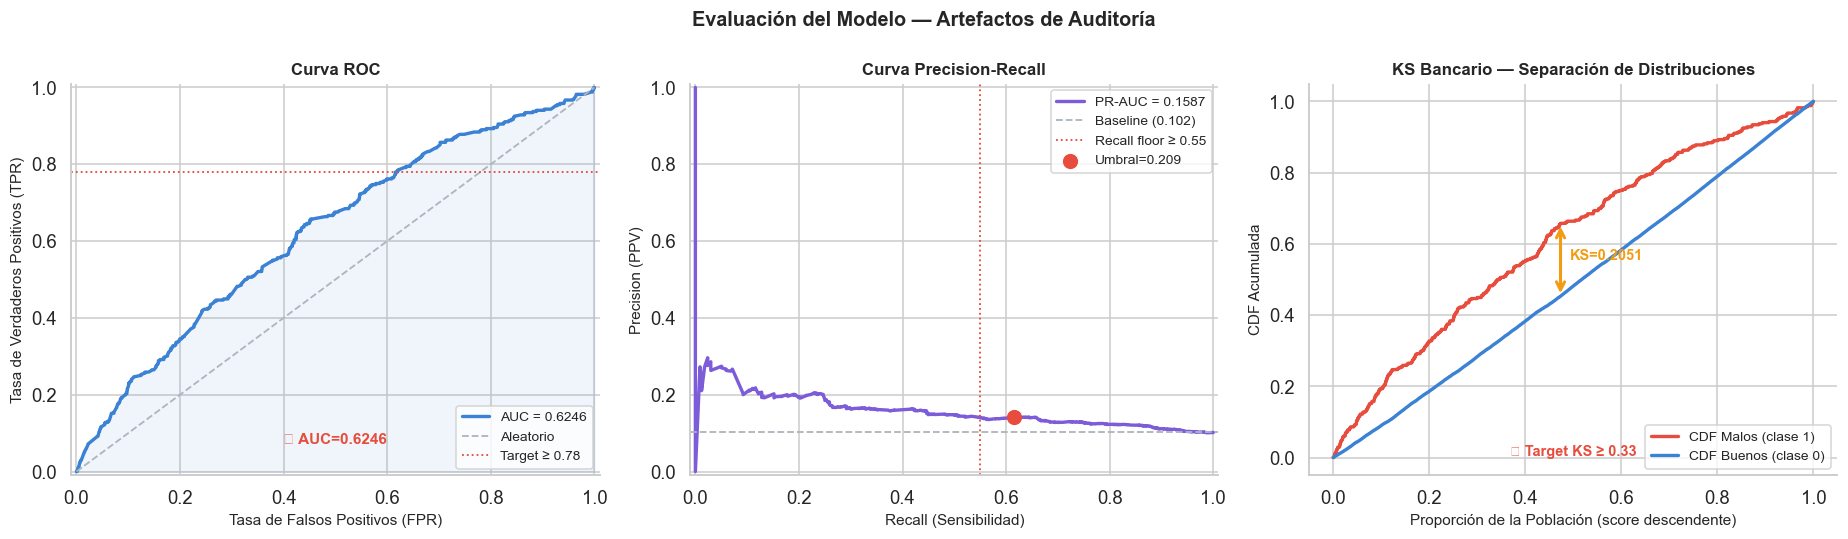


✅ Gráficos de evaluación generados.


In [5]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc as sklearn_auc

# --- Inferencia sobre test ---
y_scores_test: np.ndarray = train_result.model.predict_proba(split.X_test)[:, 1]
threshold = train_result.optimal_threshold
y_pred_test = (y_scores_test >= threshold).astype(int)

# --- Métricas completas ---
metrics = evaluate_model(
    model_result=train_result,
    X_test=split.X_test,
    y_test=split.y_test,
    iteration_name="LightGBM_walkthrough_audit",
    notes="Ejecutado desde demo_pipeline_walkthrough.ipynb — auditoría human-in-the-loop.",
)

print(f"\n{'═'*55}")
print(f"  RESULTADOS SOBRE TEST SET (holdout temporal)")
print(f"{'═'*55}")
row_fmt = "  {:<20}: {:>8.4f}   {}"
rows = [
    ("ROC-AUC",    metrics["roc_auc"],         "≥ 0.78  " + ("✅" if metrics["roc_auc"] >= 0.78 else "❌")),
    ("KS",         metrics["ks"],              "≥ 0.33  " + ("✅" if metrics["ks"] >= 0.33 else "❌")),
    ("Recall c1",  metrics["recall_class1"],   "≥ 0.55  " + ("✅" if metrics["recall_class1"] >= 0.55 else "❌")),
    ("PR-AUC",     metrics["pr_auc"],          "informativo"),
    ("Precision c1",metrics["precision_class1"],"informativo"),
    ("F1-Score",   metrics["f1_score"],        "informativo"),
    ("Accuracy",   metrics["accuracy"],        "⚠️  NO es KPI (ADR-006)"),
    ("Latencia P95",metrics["latency_ms"]/1000, "< 0.050s " + ("✅" if metrics["latency_ms"] < 50 else "❌")),
]
for name, val, status in rows:
    print(row_fmt.format(name, val, status))
print(f"{'═'*55}")

# ===========================================================================
# GRÁFICOS DE EVALUACIÓN
# ===========================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Evaluación del Modelo — Artefactos de Auditoría", fontsize=13, fontweight="bold")

# ── Gráfico 1: Curva ROC-AUC ──────────────────────────────────────────────
ax1 = axes[0]
fpr, tpr, _ = roc_curve(split.y_test, y_scores_test)
roc_auc_val = metrics["roc_auc"]

ax1.plot(fpr, tpr, color="#3b82d4", lw=2.2, label=f"AUC = {roc_auc_val:.4f}")
ax1.plot([0, 1], [0, 1], color="#adb5bd", lw=1.2, linestyle="--", label="Aleatorio")
ax1.axhline(y=0.78, color="#e74c3c", lw=1.2, linestyle=":", label="Target ≥ 0.78")
ax1.fill_between(fpr, tpr, alpha=0.08, color="#3b82d4")
ax1.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=10)
ax1.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=10)
ax1.set_title("Curva ROC", fontsize=11, fontweight="bold")
ax1.legend(loc="lower right", fontsize=9)
ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.01])
auc_color = "#27ae60" if roc_auc_val >= 0.78 else "#e74c3c"
ax1.annotate(
    f"{'✅' if roc_auc_val >= 0.78 else '❌'} AUC={roc_auc_val:.4f}",
    xy=(0.5, 0.08), xycoords="axes fraction",
    ha="center", fontsize=10, color=auc_color, fontweight="bold",
)

# ── Gráfico 2: Curva Precision-Recall ────────────────────────────────────
ax2 = axes[1]
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(split.y_test, y_scores_test)
pr_auc_val = metrics["pr_auc"]
baseline_pr = split.y_test.mean()

ax2.plot(recall_vals, precision_vals, color="#7c5cd8", lw=2.2, label=f"PR-AUC = {pr_auc_val:.4f}")
ax2.axhline(y=baseline_pr, color="#adb5bd", lw=1.2, linestyle="--",
            label=f"Baseline ({baseline_pr:.3f})")
ax2.axvline(x=0.55, color="#e74c3c", lw=1.2, linestyle=":", label="Recall floor ≥ 0.55")

# Marcar el umbral óptimo en la curva PR
optimal_idx = np.argmin(np.abs(thresholds_pr - threshold))
ax2.scatter(
    recall_vals[optimal_idx], precision_vals[optimal_idx],
    color="#e74c3c", zorder=5, s=80, label=f"Umbral={threshold:.3f}",
)
ax2.set_xlabel("Recall (Sensibilidad)", fontsize=10)
ax2.set_ylabel("Precision (PPV)", fontsize=10)
ax2.set_title("Curva Precision-Recall", fontsize=11, fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.01])

# ── Gráfico 3: KS Bancario ────────────────────────────────────────────────
ax3 = axes[2]
df_ks = pd.DataFrame({"score": y_scores_test, "target": split.y_test.values})
df_ks = df_ks.sort_values("score", ascending=False).reset_index(drop=True)
n_pos = int(df_ks["target"].sum())
n_neg = len(df_ks) - n_pos

cdf_pos = df_ks["target"].cumsum() / n_pos
cdf_neg = (1 - df_ks["target"]).cumsum() / n_neg
x_axis = np.linspace(0, 1, len(df_ks))

ax3.plot(x_axis, cdf_pos.values, color="#e74c3c", lw=2.2, label="CDF Malos (clase 1)")
ax3.plot(x_axis, cdf_neg.values, color="#3b82d4", lw=2.2, label="CDF Buenos (clase 0)")

# Marcar KS máximo
ks_diffs = (cdf_pos - cdf_neg).abs()
ks_idx = ks_diffs.argmax()
ks_val = metrics["ks"]

ax3.annotate(
    "",
    xy=(x_axis[ks_idx], cdf_pos.iloc[ks_idx]),
    xytext=(x_axis[ks_idx], cdf_neg.iloc[ks_idx]),
    arrowprops=dict(arrowstyle="<->", color="#f39c12", lw=2.0),
)
ax3.text(
    x_axis[ks_idx] + 0.02,
    (cdf_pos.iloc[ks_idx] + cdf_neg.iloc[ks_idx]) / 2,
    f"KS={ks_val:.4f}",
    fontsize=9.5, color="#f39c12", fontweight="bold",
)
ks_color_text = "✅" if ks_val >= 0.33 else "❌"
ax3.annotate(
    f"{ks_color_text} Target KS ≥ 0.33",
    xy=(0.5, 0.05), xycoords="axes fraction",
    ha="center", fontsize=9.5,
    color="#27ae60" if ks_val >= 0.33 else "#e74c3c", fontweight="bold",
)
ax3.set_xlabel("Proporción de la Población (score descendente)", fontsize=10)
ax3.set_ylabel("CDF Acumulada", fontsize=10)
ax3.set_title("KS Bancario — Separación de Distribuciones", fontsize=11, fontweight="bold")
ax3.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()
print("\n✅ Gráficos de evaluación generados.")

---
## Celda 6 — Decisión Humana: Aprobación / Rechazo

Esta celda requiere **intervención explícita del Data Scientist**.

**Checklist de aprobación:**

| Criterio | Target | Estado |
|---|---|---|
| ROC-AUC ≥ 0.78 | Obligatorio | Ver celda 5 |
| KS ≥ 0.33 | Obligatorio | Ver celda 5 |
| Recall clase 1 ≥ 0.55 | **Restricción dura** (costo FN) | Ver celda 5 |
| Latencia P95 < 50ms | Obligatorio | Ver celda 5 |
| best_iteration > 10 | Señal de salud | Ver celda 4 |

**Instrucción:** Editar la variable `HUMAN_DECISION` abajo:
- `"APPROVED"` → guarda en `reports/metrics.json` con tag `Human_Validated_Approved` y habilita la fase **Docs**.
- `"REJECTED"` → registra el rechazo con motivo. No guarda métricas. Volver a Iteración 2.

> ⚠️ **Esta variable debe ser modificada manualmente. No ejecutar con el valor por defecto `"PENDING"`.**

In [6]:
import json
from datetime import datetime, timezone

# ============================================================
#  ✋ ACCIÓN REQUERIDA — Editar esta variable
# ============================================================
HUMAN_DECISION: str = "PENDING"   # Opciones: "APPROVED" | "REJECTED"
REJECTION_REASON: str = ""         # Solo si REJECTED: texto libre con el motivo
# ============================================================

# --- Verificación automática de umbrales ---
THRESHOLDS = {
    "roc_auc":      (metrics["roc_auc"],         0.78,  "ROC-AUC ≥ 0.78"),
    "ks":           (metrics["ks"],              0.33,  "KS ≥ 0.33"),
    "recall_class1":(metrics["recall_class1"],   0.55,  "Recall ≥ 0.55  ★ restricción dura"),
    "latency_ms":   (metrics["latency_ms"],      50.0,  "Latencia P95 < 50ms"),
}

all_pass = True
print(f"\n{'═'*60}")
print(f"  CHECKLIST DE UMBRALES — VALIDACIÓN AUTOMÁTICA")
print(f"{'═'*60}")
for key, (val, thr, desc) in THRESHOLDS.items():
    if key == "latency_ms":
        passed = val < thr
        symbol = "✅" if passed else "❌"
    else:
        passed = val >= thr
        symbol = "✅" if passed else "❌"
    all_pass = all_pass and passed
    print(f"  {symbol}  {desc:<38}  valor={val:.4f}")

print(f"{'═'*60}")
print(f"  Resultado automático: {'✅ TODOS LOS UMBRALES SUPERADOS' if all_pass else '❌ UMBRALES NO ALCANZADOS'}")
print(f"{'═'*60}")

# --- Proceso de decisión humana ---
if HUMAN_DECISION == "PENDING":
    print("\n⚠️  ACCIÓN PENDIENTE: Editar 'HUMAN_DECISION' a \"APPROVED\" o \"REJECTED\" y re-ejecutar esta celda.")

elif HUMAN_DECISION == "APPROVED":
    # Tag de aprobación humana
    validated_metrics = {
        **metrics,
        "iteration": "Human_Validated_Approved",
        "timestamp": datetime.now(tz=timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "notes": (
            f"[HUMAN APPROVED] Auditoría completada desde demo_pipeline_walkthrough.ipynb. "
            f"Todos los umbrales {'superados ✅' if all_pass else 'NO superados ❌ — aprobación manual override'}. "
            f"Notas adicionales: {REJECTION_REASON or 'N/A'}."
        ),
    }

    update_metrics_json(validated_metrics, output_path=METRICS_JSON_PATH)

    print(f"\n{'═'*60}")
    print("  ✅ MODELO APROBADO POR EL DATA SCIENTIST")
    print(f"  Tag guardado: 'Human_Validated_Approved'")
    print(f"  Archivo actualizado: {METRICS_JSON_PATH}")
    print(f"{'═'*60}")

    # Confirmar escritura leyendo el archivo
    with open(METRICS_JSON_PATH, "r", encoding="utf-8") as f:
        saved = json.load(f)
    last_entry = saved["history"][-1]
    print(f"\n  Último registro en history:")
    print(f"    iteration : {last_entry['iteration']}")
    print(f"    timestamp : {last_entry['timestamp']}")
    print(f"    roc_auc   : {last_entry['roc_auc']}")
    print(f"    ks        : {last_entry['ks']}")
    print(f"    recall_c1 : {last_entry['recall_class1']}")
    print(f"\n  ➡️  Próximo paso: iniciar fase Docs → docs/3_final_pipeline.md")

elif HUMAN_DECISION == "REJECTED":
    rejected_entry = {
        **metrics,
        "iteration": "Human_Validated_Rejected",
        "timestamp": datetime.now(tz=timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "notes": (
            f"[HUMAN REJECTED] Motivo: {REJECTION_REASON or 'No especificado'}. "
            f"Umbrales {'superados' if all_pass else 'no alcanzados'}. "
            "Requiere iteración adicional."
        ),
    }
    update_metrics_json(rejected_entry, output_path=METRICS_JSON_PATH)

    print(f"\n{'═'*60}")
    print("  ❌ MODELO RECHAZADO POR EL DATA SCIENTIST")
    print(f"  Motivo registrado: {REJECTION_REASON or 'Sin especificar'}")
    print(f"  Tag guardado    : 'Human_Validated_Rejected'")
    print(f"  Archivo actualizado: {METRICS_JSON_PATH}")
    print(f"{'═'*60}")
    print(f"\n  ➡️  Próximo paso: Iteración 2 — ajustar hiperparámetros y re-entrenar.")
    print(f"      Sugerencias (memory.md):")
    print(f"        • learning_rate=0.01, n_estimators=1000, early_stopping_rounds=100")
    print(f"        • Analizar distribución temporal de {TARGET_COL} por periodo FECHA")

else:
    print(f"\n⛔ HUMAN_DECISION='{HUMAN_DECISION}' no es válido. Usar 'APPROVED' o 'REJECTED'.")


════════════════════════════════════════════════════════════
  CHECKLIST DE UMBRALES — VALIDACIÓN AUTOMÁTICA
════════════════════════════════════════════════════════════
  ❌  ROC-AUC ≥ 0.78                          valor=0.6246
  ❌  KS ≥ 0.33                               valor=0.2051
  ✅  Recall ≥ 0.55  ★ restricción dura       valor=0.6161
  ✅  Latencia P95 < 50ms                     valor=2.6890
════════════════════════════════════════════════════════════
  Resultado automático: ❌ UMBRALES NO ALCANZADOS
════════════════════════════════════════════════════════════

⚠️  ACCIÓN PENDIENTE: Editar 'HUMAN_DECISION' a "APPROVED" o "REJECTED" y re-ejecutar esta celda.
